# Homework 4

## Your Name Here (or your names here if you are pair programming)

Leia Nayana Das (lnd749)

Javier Diaz de Sandi Viramontes (jd52288)

## Linear Regression with Gradient Descent

Your task in this assignment is to implement Multiple Linear Regression. 

We will use the New York City Taxi trip reports in the Year 2013. 
The dataset was released under the FOIL (The Freedom of Information Law) and made public by Chris Whong (\url{https://chriswhong.com/open-data/foil_nyc_taxi/}).



# Taxi Data Set
The data set itself is a simple text file. Each taxi trip report is a different line in the file. Among other things, each trip report 
includes the starting point, the drop-off point, corresponding timestamps, and information related to the payment. The data are reported 
by the time that the trip ended, i.e., upon arriving in the order of the drop-off timestamps. 
The attributes present on each line of the file are, in order:



| index | **Attribute** | **Description** |
| --- | --- | --- |
| 0 | medallion           |  an md5sum of the identifier of the taxi - vehicle bound (Taxi ID)  | 
| 1 | hack license       |  an md5sum of the identifier for the taxi license (Driver ID)  |  
| 2 | pickup datetime    | time when the passenger(s) were picked up  |  
| 3 | dropoff datetime   | time when the passenger(s) were dropped off  | 
| 4 | trip time in secs | duration of the trip  |  
| 5 | trip distance | trip distance in miles  |  
| 6 | pickup longitude | longitude coordinate of the pickup location  |  
| 7 | pickup latitude | latitude coordinate of the pickup location  |  
| 8 | dropoff longitude | longitude coordinate of the drop-off location   |  
| 9 | dropoff latitude | latitude coordinate of the drop-off location  | 
| 10 | payment type | the payment method -credit card or cash  |  
| 11 | fare amount | fare amount in dollars  |  
| 12 | surcharge | surcharge in dollars  |  
| 13 | mta tax | tax in dollars  |  
| 14 | tip amount | tip in dollars  |  
| 15 | tolls amount | bridge and tunnel tolls in dollars  |  
| 16 | total amount | total paid amount in dollars  |  




The data files are in comma separated values (CSV) format. Example lines from the file are:

07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,\\
2013-01-01,00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,\\
40.715008,CSH,3.50,0.50,0.50,0.00,0.00,4.50

22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,\\
2013-01-01,00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,\\
CSH,27.00,0.00,0.50,0.00,0.00,27.50

0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,\\
2013-01-01,00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897\\
73.965897,40.760445,CSH,4.00,0.50,0.50,0.00,0.00,5.00



In [44]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

In [12]:
df = pd.read_csv('nyc-taxi-data.csv.bz2')
df

,07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,2013-01-01 00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,40.715008,CSH,3.50,0.50,0.50.1,0.00,0.00.1,4.50
0,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.00,0.0,27.50
1,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
2,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
4,5FAA7F69213D26A42FA435CA9511A4FF,00B7691D86D96AEBD21DD9E138F90840,2013-01-01 00:02:00,2013-01-01 00:03:00,60,0.00,0.000000,0.000000,0.000000,0.000000,CRD,2.5,0.5,0.5,0.25,0.0,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,A0AFE6B722F15B7A0FDFEEA954BE316A,93D505C96BD248DC390FD47F747D762D,2013-01-01 03:44:00,2013-01-01 03:46:00,120,0.79,-73.963593,40.710941,-74.027779,40.629894,CSH,4.5,0.5,0.5,0.00,0.0,5.50
49995,A0DEAEC3D5592AE94B876356F12F8158,6A35995FBD5399AB131B89623C344782,2013-01-01 03:35:00,2013-01-01 03:46:00,660,2.41,-73.955833,40.768272,-73.987724,40.775490,CRD,10.0,0.5,0.5,2.10,0.0,13.10
49996,A154EFA0695A29423B078C7F5D5B2CB5,F38E7C3381F28C9B3E51C0B6DDBDF68A,2013-01-01 03:40:00,2013-01-01 03:46:00,360,1.63,-73.963951,40.709934,-73.949364,40.695381,CRD,7.0,0.5,0.5,2.25,0.0,10.25
49997,A2B97CECFEA4C8DE45D8FC251E80AF1D,68AE01DDBDEDDFF772905561744A1072,2013-01-01 03:34:00,2013-01-01 03:46:00,720,4.04,-73.952759,40.776524,-73.983093,40.738796,CRD,14.5,0.5,0.5,3.00,0.0,18.50


## Task - 1
The dataset is a real-world dataset and many records are incorrect and wrong. Your task is first to describe at least 4 data clean up tasks and implement them on this data set.

For example, you can define to remove lines with the following property, if a taxi trip (one of the data rows) has a travel distance less than 1 mile and total amount of more than 20 dollar, then it is an wrong record. 

Another example is that you would expect to have a float number (e.g., index 12 to 16) and then you got a String in that position. You can remove such lines from your data. 

Perform the following cleanup tasks:
1. Add column headers based on the description above (no need to describe).
2. Drop rows with a travel distance < 1 mile and a total fare > $20 (no need to describe). Both conditions need to be met.
3. Your own task (please describe your task in a comment/cell).
4. Your own task (please describe your task in a comment/cell).

**(4 points)**

In [47]:
dfWithColumns = pd.read_csv('nyc-taxi-data.csv', header = None)
dfWithColumns.columns = ['medallion','hack license','pickup datetime',
                         'dropoff datetime','trip time in secs.','trip distance',
                         'pickup longitude', 'pickup latitude','dropoff longitude',
                         'dropoff latitude','payment type','fare amount',
                         'surcharge', 'mta tax', 'tip amount','tolls amount',
                         'total amount']


In [41]:
dfCleaned_1 = dfWithColumns[~((dfWithColumns['trip distance'] < 1) & (dfWithColumns['total amount'] > 20))]


In [40]:
# removing outliers from pickup coordinates. Constraining to -75 < longitude < -70 and 40 < latitude < 42
dfCleaned_2 = dfCleaned_1[((dfCleaned_1['pickup longitude'] < -70) | (dfCleaned_1['pickup longitude'] > -75))]
dfCleaned_3 = dfCleaned_2[~((dfCleaned_2['pickup latitude'] < 40) | (dfCleaned_2['pickup latitude'] > 42))]


In [39]:
# removing rows where the payment type is unknown
dfCleaned_4 = dfCleaned_3[((dfCleaned_3['payment type'] == "CRD") | (dfCleaned_3['payment type'] == "CSH"))]
dfCleaned_4

,medallion,hack license,pickup datetime,dropoff datetime,trip time in secs.,trip distance,pickup longitude,pickup latitude,dropoff longitude,dropoff latitude,payment type,fare amount,surcharge,mta tax,tip amount,tolls amount,total amount
0,07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,2013-01-01 00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,40.715008,CSH,3.5,0.5,0.5,0.00,0.0,4.50
2,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
4,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
6,DFBFA82ECA8F7059B89C3E8B93DAA377,CF8604E72D83840FBA1978C2D2FC9CDB,2013-01-01 00:02:00,2013-01-01 00:03:00,60,0.39,-73.981544,40.781475,-73.979439,40.784386,CRD,3.0,0.5,0.5,0.70,0.0,4.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,A0AFE6B722F15B7A0FDFEEA954BE316A,93D505C96BD248DC390FD47F747D762D,2013-01-01 03:44:00,2013-01-01 03:46:00,120,0.79,-73.963593,40.710941,-74.027779,40.629894,CSH,4.5,0.5,0.5,0.00,0.0,5.50
49996,A0DEAEC3D5592AE94B876356F12F8158,6A35995FBD5399AB131B89623C344782,2013-01-01 03:35:00,2013-01-01 03:46:00,660,2.41,-73.955833,40.768272,-73.987724,40.775490,CRD,10.0,0.5,0.5,2.10,0.0,13.10
49997,A154EFA0695A29423B078C7F5D5B2CB5,F38E7C3381F28C9B3E51C0B6DDBDF68A,2013-01-01 03:40:00,2013-01-01 03:46:00,360,1.63,-73.963951,40.709934,-73.949364,40.695381,CRD,7.0,0.5,0.5,2.25,0.0,10.25
49998,A2B97CECFEA4C8DE45D8FC251E80AF1D,68AE01DDBDEDDFF772905561744A1072,2013-01-01 03:34:00,2013-01-01 03:46:00,720,4.04,-73.952759,40.776524,-73.983093,40.738796,CRD,14.5,0.5,0.5,3.00,0.0,18.50


## Task - 2
Use the cleaned dataset from task 1.
Find out the correlations between trip distance, travel time and fare amount. Visualize the correlations in form of Scatterplot matrix. 
Describe the correlations between them. **(4 points)**

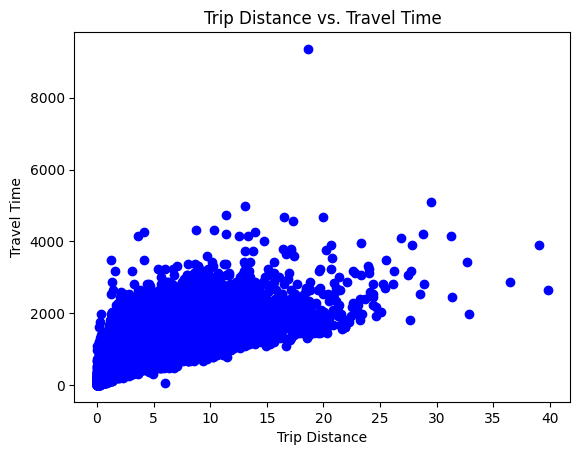

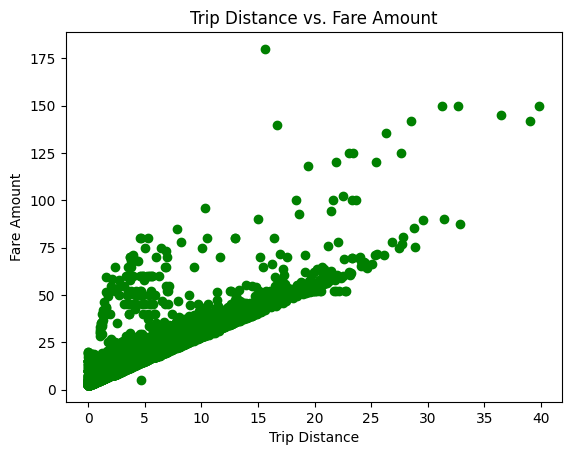

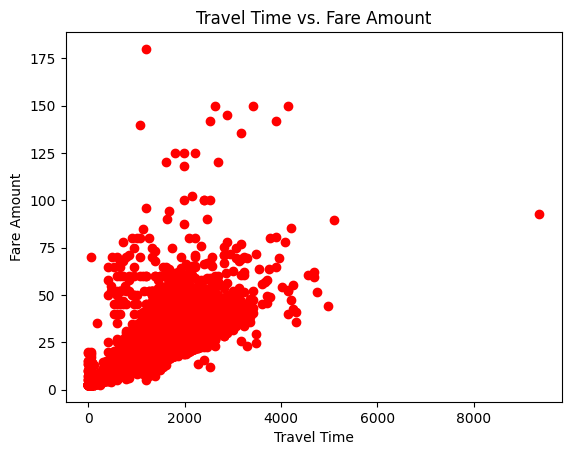

In [54]:
plt.figure()
plt.scatter(dfCleaned_4['trip distance'],dfCleaned_4['trip time in secs.'],color='blue')
plt.xlabel("Trip Distance")
plt.ylabel("Travel Time")
plt.title("Trip Distance vs. Travel Time")
plt.show()

plt.scatter(dfCleaned_4['trip distance'],dfCleaned_4['fare amount'],color='green')
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Trip Distance vs. Fare Amount")
plt.show()

plt.scatter(dfCleaned_4['trip time in secs.'],dfCleaned_4['fare amount'],color='red')
plt.xlabel("Travel Time")
plt.ylabel("Fare Amount")
plt.title("Travel Time vs. Fare Amount")
plt.show()

In order of weakest to strongest positive correlation...
1. Travel Time vs. Fare Amount
2. Trip Distance vs. Travel Time
3. Trip Distance vs. Fair Amount

All three have positive correlations, but the green graph has the strongest positive correlation.

## Task - 3
Use the cleaned dataset from task 1.
We want to find a simple line to our data (distance, money). 
We want to use trip distance, and fare amount. Use the **Scikit-learn** library to fit a line into the data. **(2 points)**

* Provide the Regression Cofficients of your model
* Write down your linear regression equation. 
* Use your model to predict the fare amount for a 3 miles trip. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [95]:
from sklearn.linear_model import LinearRegression

X = np.array(dfCleaned_4[['trip distance']])
y = np.array(dfCleaned_4[['fare amount']])

model = LinearRegression()
model.fit(X,y)

coefficientArray = model.coef_[0]
coefficient = coefficientArray.astype(float)
interceptArray = model.intercept_[0]
intercept = interceptArray.astype(float)

# regression equation is y = 2.862x + 3.735

estMiles = 3.0
estFare = coefficient*estMiles + intercept

estFare


array([12.32108185])

## Task - 4
Fit a Multiple Linear Regression hyperplane into this data. We are interested to predict total amount out of trip distance, tavel time. **(4 points)**
Use the **Scikit-learn** library.

* Provide the Regression Cofficients of your model
* Write down your Multiple Linear Regression equation. 
* Use your model to predict the total amount for a 3 miles trip and 6 min travel time. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [93]:
X = np.array(dfCleaned_4[['trip distance','trip time in secs.']])
y = np.array(dfCleaned_4[['fare amount']])

model = LinearRegression()
model.fit(X,y)


# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)

coefList = model.coef_.tolist()
coefList


coefficient_1 = float(coefList[0][0])
coefficient_2 = float(coefList[0][1])
intercept = float(model.intercept_[0])


# regression equation is y = 2.151(x1) + 0.00527(x2) + 1.95

estMiles = 3.0
estTime = 6*60
estFare = coefficient_1*estMiles + coefficient_2*estTime + intercept

estFare



10.30254555259664

## Task - 5 - Gradient Descent
Implement the gradient descent optimization to find the optimal parameters for our Simple Linear Regression model of task 3. **(6 points)**

* Define and set your learning rate (start with a very small number and increase it if your GC works)
* Instantiate all coefficients from zero
* Run maximum 400 interations. You can stop if your cost converge with a precision of 0.01 
* Print and visualize the optimization costs
* Provide the Regression Coefficients of your model after stop or convergance. 

Please note that a visualization **is** required, unlike in Task 3 and 4.

Iteration No.= 0  m = 1.2440314545009286  b= 0.25347294545009286  Cost= 233.97074652558112
Iteration No.= 1  m = 2.032894747336129  b= 0.424169511798427  Cost= 102.1457212805042
Iteration No.= 2  m = 2.5325050800921174  b= 0.5421767553354752  Cost= 48.86020647778962
Iteration No.= 3  m = 2.84830460612952  b= 0.6266162988274471  Cost= 27.296337568564322
Iteration No.= 4  m = 3.04730370099094  b= 0.6896410160041627  Cost= 18.545088801724237
Iteration No.= 5  m = 3.172088611369518  b= 0.7389750010592882  Cost= 14.969383831530767
Iteration No.= 3  m = 2.84830460612952  b= 0.6266162988274471  Cost= 27.296337568564322
Iteration No.= 4  m = 3.04730370099094  b= 0.6896410160041627  Cost= 18.545088801724237
Iteration No.= 5  m = 3.172088611369518  b= 0.7389750010592882  Cost= 14.969383831530767
Iteration No.= 6  m = 3.249723583975295  b= 0.779527767909509  Cost= 13.484712899920906
Iteration No.= 7  m = 3.297408338711645  b= 0.8144201047556964  Cost= 12.845277834952874
Iteration No.= 8  m = 3.32

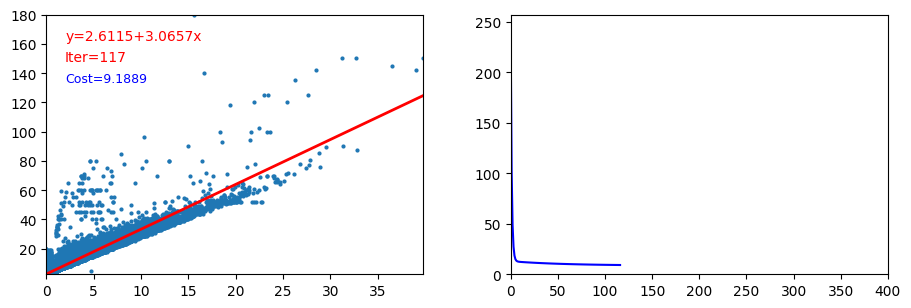

In [133]:
# Using cleaned data: simple linear regression with gradient descent visualization
X = np.array(dfCleaned_4[['trip distance']])
y = np.array(dfCleaned_4[['fare amount']])

fig = plt.figure(figsize=(10,4), dpi=100)
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.set_xlim(left=np.min(X), right=np.max(X))
ax1.set_ylim(bottom=np.min(y), top=np.max(y))
ax1.plot(X, y, 'o', markersize=2)

plt.tight_layout(pad=4.0)

# Initialize coefficients at zero (per assignment)
b1 = 0.0
b0 = 0.0

# Hyperparameters (tune as needed)
learningRate = 0.01
numIteration = 400
precision = 0.01

n = float(len(y))

oldCost = float('inf')
xx, costHist = [], []

for val in range(numIteration):
    # Predictions
    yPred = b1 * X + b0
    cost = np.mean((yPred - y)**2)

    # Check convergence
    if abs(cost - oldCost) <= precision:
        print("Stopped at iteration", val)
        break

    # Gradients (MSE)
    b1Gradient = (2.0/n) * np.sum(X * (yPred - y))
    b0Gradient = (2.0/n) * np.sum(yPred - y)

    # Parameter updates
    b1 -= learningRate * float(b1Gradient)
    b0 -= learningRate * float(b0Gradient)

    oldCost = cost

    # Visualization update
    xVals = np.array([np.min(X), np.max(X)])
    yVals = b1 * xVals + b0

    ax1.clear()
    ax1.set_xlim(left=np.min(X), right=np.max(X))
    ax1.set_ylim(bottom=np.min(y), top=np.max(y))
    ax1.plot(X, y, 'o', markersize=2)
    ax1.plot(xVals, yVals, '-', color='red', linewidth=2.0)

    # Text positions computed relative to data range to avoid hard-coded numbers
    x_text = np.min(X) + 0.05 * (np.max(X) - np.min(X))
    y_top = np.min(y) + 0.9 * (np.max(y) - np.min(y))
    ax1.text(x_text, y_top, f"y={b0:.4f}+{b1:.4f}x", fontsize=10, color='red')
    ax1.text(x_text, y_top - 0.08*(np.max(y)-np.min(y)), f"Iter={val+1}", fontsize=10, color='red')
    ax1.text(x_text, y_top - 0.16*(np.max(y)-np.min(y)), f"Cost={cost:.4f}", fontsize=9, color='blue')

    xx.append(val)
    costHist.append(cost)

    ax2.clear()
    ax2.plot(xx, costHist, color='blue')
    ax2.set_xlim(left=0, right=numIteration)
    ax2.set_ylim(bottom=0, top=max(max(costHist) * 1.1, 1.0))

    fig.canvas.draw()

    if val % 1 == 0:
        print("Iteration No.=", val, " m =", b1, " b=", b0, " Cost=", cost)

print("Final iteration: m =", b1, " b=", b0)
